# arc_sys_sci_pond_ice_prop_20260324

Notebook to create figures related to pond ice physical properties for 2026 Arctic System Science conference

@author: David Clemens-Sewall

In [1]:
import os
import glob
import re
import warnings
import datetime

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns

from openpyxl import load_workbook
from matplotlib.colors import Normalize
from matplotlib.ticker import FixedFormatter

%matplotlib inline

In [90]:
# Set default color cycle:
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["dodgerblue", "darkgray"]) 

## Load Data

In [2]:
# Paths
ic_data_root = os.path.join('..', 'data', 'ice_coring')
transect_data_root = os.path.join('..', 'data', 'transects_from_max')

In [74]:
# Ice core data is very complicated, especially the vertical reference frame
# Define a class for representing ice cores
class IceCore:
    """
    Class representing data from an individual ice core.

    Attributes:
        station (str): Station number (1, 2, or 3) as a string.
        visit (str): Visit letter ([a-d]).
        file_path (str): Path to the xlsx file containing core data.
        core (str): Name of the core.
        site (str): Site name
        timestamp (datetime.datetime): Timestamp for the core.
        hi (float): Ice thickness (measured by a thickness gauge) in meters.
        draft (float): Draft (measured by a thickness gauge) in meters.
        length (float): Total core length in meters.
        freeboard (float): Freeboard (ice thickness - draft) in meters.
        snow_depths (array): Array of snow depths in meters.
        hs (float): Mean snow depth in meters.
        hp (float): Pond depth in meters.
        ponded (bool): Whether the ice was ponded.
        age (str): Sea ice age.
        data (Pandas.DataFrame): Dataframe containing data for this core.
        comments (Pandas.DataFrame): Dataframe containing comments for this core.
        units (dict): Mapping of variable names in self.data to units.
        variables (list): List of data variables that this ice core has.
    """
    
    def __init__(self, station, visit, file_path):
        """
        Initialize an IceCore object and load basic core metadata.

        Parameters:
            station (str): Station number (1, 2, or 3) as a string.
            visit (str): Visit letter ([a-d]).
            file_path (str): Path to the xlsx file containing core data.
        """
        # Store attributes
        self.station = station
        self.visit = visit
        self.file_path = file_path

        # Open excel workbook
        wb = load_workbook(file_path, read_only=True, data_only=True)
        ws_core = wb['metadata-core']
        ws_coring = wb['metadata-coring']

        # Get the core name from the workbook and check that it matches the filename
        core_fn = os.path.basename(file_path)[:-5]
        core_wb = ws_core['C1'].value
        if core_fn != core_wb:
            warnings.warn(f"Core name from filename does not match workbook, using core name from filename: {core_fn}",
                          category=RuntimeWarning)
        self.core = core_fn
        self.site = ws_coring['C4'].value

        ## Get basic parameters
        # time
        if ws_core['D2'].value == 'UTC':
            tzinfo = datetime.timezone.utc
        else:
            raise RuntimeError('Timezone is not UTC, need to implement support for other timezones')
        date = ws_core['C2'].value
        time = ws_core['C3'].value
        if time is None:
            time = ws_coring['C13'].value
        if time is None:
            warnings.warn(f"{core_fn} is missing time info setting to 12 utc")
            time = datetime.time(hour=12)
        self.timestamp = datetime.datetime.combine(date, time, tzinfo=tzinfo)
        # ice measurements
        self.hi = ws_core['C7'].value
        self.draft = ws_core['C8'].value
        self.freeboard = ws_core['C9'].value
        self.length = ws_core['C10'].value
        if self.length is None:
            raise RuntimeError(f"{self.core} is missing core length")
        # Account for potential missing core data
        if self.hi is None:
            warnings.warn(f"{self.core} is missing ice thickness, using core length",
                          category=RuntimeWarning)
            self.hi = self.length
        if (self.draft is None) and (self.freeboard is None):
            warnings.warn(f"{self.core} is missing freeboard and draft",
                         category=RuntimeWarning)
        elif self.freeboard is None:
            self.freeboard = self.hi - self.draft
        elif self.draft is None:
            self.draft = self.hi - self.freeboard
        self.age = ws_coring['C20'].value
        # snow measurements
        for value in ws_coring.iter_rows(min_row=16, max_row=16, min_col=3, max_col=8, values_only=True):
            self.snow_depths = np.array(value, dtype=float)
        if np.isnan(self.snow_depths).all():
            self.hs = 0
        else:
            self.hs = np.nanmean(self.snow_depths)
        # pond measurements
        self.hp = ws_coring['C19'].value
        if self.hp is None:
            self.ponded = False
            self.hp = 0
        else:
            self.ponded = True

        ## Initialize the data and comments dataframes
        idx = pd.MultiIndex.from_tuples([], names=('variable', 'depth_top', 'depth_bottom', 'depth_center'))
        self.data = pd.DataFrame(columns=['value'], index=idx)
        self.comments = pd.DataFrame(columns=['description', 'comment'], index=idx)
        self.units = {}
        self.variables = []
        wb.close()

    def load_salinity(self):
        """Loads salinity data if present in file."""

        # Get temperature sheet
        wb = load_workbook(self.file_path, read_only=True, data_only=True)
        ws = wb['SALO18']

        # If there is no data at all in the temperature sheet, return
        if ws['A5'].value is None:
            return
        # Read in values
        ls_d_t = []
        ls_d_b = []
        ls_s = []
        ls_c = []
        for row in ws.iter_rows(min_row=5, min_col=1, max_col=14):
            d_t = row[0].value
            if d_t is None:
                break
            else:
                ls_d_t.append(d_t)
                ls_d_b.append(row[1].value)
                ls_s.append(row[4].value)
                ls_c.append(row[13].value)
        # Create temporary dataframes and concatenate
        df_data_temp = pd.DataFrame({'variable': 'salinity',
                                     'depth_top': ls_d_t,
                                     'depth_bottom': ls_d_b,
                                     'depth_center': np.nan,
                                     'value': ls_s})
        df_data_temp['depth_center'] = (df_data_temp['depth_top'] + df_data_temp['depth_bottom'])/2.0
        df_data_temp.set_index(['variable', 'depth_top', 'depth_bottom', 'depth_center'],
                               inplace=True)
        df_comm_temp = pd.DataFrame({'variable': 'salinity',
                                     'depth_top': ls_d_t,
                                     'depth_bottom': ls_d_b,
                                     'depth_center': np.nan,
                                     'description': '',
                                     'comment': ls_c})
        df_comm_temp['depth_center'] = (df_comm_temp['depth_top'] + df_comm_temp['depth_bottom'])/2.0
        df_comm_temp.set_index(['variable', 'depth_top', 'depth_bottom', 'depth_center'],
                               inplace=True)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            self.data = pd.concat([self.data, df_data_temp])
            self.comments = pd.concat([self.comments, df_comm_temp])
        # Update variables and units fields
        self.variables.append('salinity')
        self.units['salinity'] = ws['E4'].value
        wb.close()

    def load_densimetry(self):
        """Loads densimetry data if present in file."""

        # Get temperature sheet
        wb = load_workbook(self.file_path, read_only=True, data_only=True)
        ws = wb['Density-densimetry']

        # If there is no data at all in the temperature sheet, return
        if ws['A4'].value is None:
            return
        # Read in values
        ls_d_t = []
        ls_d_b = []
        ls_r = []
        ls_c = []
        for row in ws.iter_rows(min_row=4, min_col=1, max_col=8):
            d_t = row[0].value
            if d_t is None:
                break
            else:
                ls_d_t.append(d_t)
                ls_d_b.append(row[1].value)
                ls_r.append(row[6].value)
                ls_c.append(row[7].value)
        # Create temporary dataframes and concatenate
        df_data_temp = pd.DataFrame({'variable': 'density',
                                     'depth_top': ls_d_t,
                                     'depth_bottom': ls_d_b,
                                     'depth_center': np.nan,
                                     'value': ls_r})
        df_data_temp['depth_center'] = (df_data_temp['depth_top'] + df_data_temp['depth_bottom'])/2.0
        df_data_temp.set_index(['variable', 'depth_top', 'depth_bottom', 'depth_center'],
                               inplace=True)
        df_comm_temp = pd.DataFrame({'variable': 'density',
                                     'depth_top': ls_d_t,
                                     'depth_bottom': ls_d_b,
                                     'depth_center': np.nan,
                                     'description': '',
                                     'comment': ls_c})
        df_comm_temp['depth_center'] = (df_comm_temp['depth_top'] + df_comm_temp['depth_bottom'])/2.0
        df_comm_temp.set_index(['variable', 'depth_top', 'depth_bottom', 'depth_center'],
                               inplace=True)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            self.data = pd.concat([self.data, df_data_temp])
            self.comments = pd.concat([self.comments, df_comm_temp])
        # Update variables and units fields
        self.variables.append('density')
        self.units['density'] = ws['G3'].value
        wb.close()

    def load_temperature(self):
        """Loads temperature data if present in file."""

        # Get temperature sheet
        wb = load_workbook(self.file_path, read_only=True, data_only=True)
        ws = wb['TEMP']

        # If there is no data at all in the temperature sheet, return
        if ws['A4'].value is None:
            return
        # Read in values
        ls_d_c = []
        ls_t = []
        ls_c = []
        for row in ws.iter_rows(min_row=4, min_col=1, max_col=3):
            d_c = row[0].value
            if d_c is None:
                break
            else:
                ls_d_c.append(d_c)
                ls_t.append(row[1].value)
                ls_c.append(row[2].value)
        # Create temporary dataframes and concatenate
        df_data_temp = pd.DataFrame({'variable': 'temperature',
                                     'depth_top': np.nan,
                                     'depth_bottom': np.nan,
                                     'depth_center': ls_d_c,
                                     'value': ls_t})
        df_data_temp.set_index(['variable', 'depth_top', 'depth_bottom', 'depth_center'],
                               inplace=True)
        df_comm_temp = pd.DataFrame({'variable': 'temperature',
                                     'depth_top': np.nan,
                                     'depth_bottom': np.nan,
                                     'depth_center': ls_d_c,
                                     'description': '',
                                     'comment': ls_c})
        df_comm_temp.set_index(['variable', 'depth_top', 'depth_bottom', 'depth_center'],
                               inplace=True)
        self.data = pd.concat([self.data, df_data_temp])
        self.comments = pd.concat([self.comments, df_comm_temp])
        # Update variables and units fields
        self.variables.append('temperature')
        self.units['temperature'] = ws['B3'].value
        wb.close()

    def plot_profile(self, ax, variable, z_ref='ice top', z_scale='absolute',
                     kind='center', linestyle='solid', color = 'C0',
                    markersize=3):
        """
        Plots a profile of a single variable from the ice core following various conventions

        Parameters:
            ax (Matplotlib Axes): Axes to plot on.
            variable (str): Variable to plot, must be in self.data
            z_ref (str): Vertical reference for profile, must be one of ['ice top',
                'sea surface', 'pond surface']. The default is 'ice top'.
            z_scale (str): How to scale z values, must be one of ['absolute', 
                'relative']. The default is 'absolute'.
            kind (str): Whether to plot values at the 'center' of ice segments
                or as a line spanning entire segment ('segment') the default is 'center'.
            linestyle (str): Line style for line.
            color (color for Matplotlib): Line color.
            markersize (float): Marker size

        Returns:
            Handle from matplotlib object.
        """
        
        # z_ref_dict for converting z_ref into z values
        z_ref_dict = {'ice top': 0,
                      'sea surface': self.freeboard,
                      'pond surface': -self.hp
                     }
        z_unit_dict = {'absolute': 'm',
                       'relative': '1',
                      }
        # Get data
        df_plot = self.data.query('variable == @variable').reset_index()
        # Adjust for z-reference
        df_plot['z_t'] = z_ref_dict[z_ref] - df_plot['depth_top']
        df_plot['z_b'] = z_ref_dict[z_ref] - df_plot['depth_bottom']
        df_plot['z_c'] = z_ref_dict[z_ref] - df_plot['depth_center']
        # If scale is relative, adjust for relative vertical position
        if z_scale == 'relative':
            if z_ref == 'pond surface':
                z_top = 0
                z_bottom = -self.hp - self.length
            else:
                z_top = z_ref_dict[z_ref]
                z_bottom = z_top - self.length
            df_plot['z_t'] = (df_plot['z_t'] - z_bottom) / (z_top - z_bottom)
            df_plot['z_b'] = (df_plot['z_b'] - z_bottom) / (z_top - z_bottom)
            df_plot['z_c'] = (df_plot['z_c'] - z_bottom) / (z_top - z_bottom)
        elif z_scale != 'absolute':
            raise RuntimeError('invalid value for z_scale')
        
        # Plot values
        if kind == 'segment':
            h = ax.vlines(df_plot['value'], df_plot['z_b'], df_plot['z_t'],
                      colors=color, linestyles=linestyle, label=self.core)
            ax.plot(df_plot['value'], df_plot['z_b'], color=color,
                    marker='o', linestyle='none', label=None,
                   markersize=markersize)
            ax.plot(df_plot['value'], df_plot['z_t'], color=color,
                    marker='o', linestyle='none', label=None,
                   markersize=markersize)
        elif kind == 'center':
            h = ax.plot(df_plot['value'], df_plot['z_c'],
                        color=color, linestyle=linestyle, label=self.core,
                        marker='o', markersize=markersize)
        else:
            raise RuntimeError('invalid value for kind')

        ax.set_ylabel(f'{z_scale} height from {z_ref} ({z_unit_dict[z_scale]})')
        ax.set_xlabel(f'{variable} ({self.units[variable]})')

        return h

    def bulk_property(self, variable):
        """
        Return the bulk (vertically-averaged) property.

        Paramters:
            variable (str): Variable name to compute bulk property.

        Returns:
            (float) bulk property.
        """

        if not variable in self.units:
            raise RuntimeError(f'{variable} not found in {self.core}')

        df_temp = self.data.query('variable == @variable').reset_index()
        df_temp['thickness'] = df_temp.depth_bottom - df_temp.depth_top
        
        return (df_temp['value']*df_temp['thickness']).sum()/df_temp['thickness'].sum()

    def total_salt(self, density=None, phi_connected=0):
        """
        Return the total amount of salk (kg/m2) in the ice column.

        Parameters:
            density (float): Disconnected ice density (g/cm3). If None,
                use density data from the core. The default is None.
            phi_connected (float): The volume fraction of the ice that is
                fully connected to the ocean, and hence unmeasured in a core
                and not part of the ice itself. The default is 0.

        Returns:
            (float) Total mass of salt in ice column (kg/m2)
        """

        # Check data is present
        if not 'salinity' in self.units:
            raise RuntimeError(f'{self.core} does not have salinity data')
        if (density is None) and (not 'density' in self.units):
            raise RuntimeError(f'{self.core} does not have requested density data')

        # Create dataframe for calculation
        if density is None:
            df_temp = self.data.query('variable in ["salinity", "density"]').reset_index(
                'variable').pivot(columns='variable', values='value')
            if df_temp.isnull().values.any():
                raise NotImplementedError(f'mismatched or missing density and salinity in {core}')
        else:
            df_temp = self.data.query('variable == "salinity"').reset_index(
                'variable', drop=True).rename(columns={'value': 'salinity'})
            df_temp['density'] = density
        df_temp = df_temp.reset_index()
        df_temp['thickness'] = df_temp.depth_bottom - df_temp.depth_top

        # Return value
        # [density] g/cm3 * 1kg/1e3g * 1e6cm3/1m3 * [thickness] m * [salinity] g/kg * 1kg/1e3g * [1 - phi_connected]
        return (df_temp.density*df_temp.thickness*df_temp.salinity*(1 - phi_connected)).sum()

In [20]:
# Load all ice core data
stations = ['1', '2', '3']
visits = ['a', 'b', 'c', 'd']

# Load each core into a dataframe
ls_s = []
ls_v = []
ls_name = []
ls_icecore = []
for station in stations:
    for visit in visits:
        filepaths = glob.glob(os.path.join(ic_data_root, f"IceStation{station}{visit}", '**', '[!~]*.xlsx'))
        for fp in filepaths:
            if os.path.basename(fp)[:3] == 'Ice':
                continue
            # load core properties
            try:
                ic = IceCore(station, visit, fp)
            except RuntimeError as err:
                print(err)
                continue
            # Load data if present
            ic.load_temperature()
            ic.load_salinity()
            ic.load_densimetry()
            # Append to lists
            ls_s.append(station)
            ls_v.append(visit)
            ls_name.append(ic.core)
            ls_icecore.append(ic)

df_cores = pd.DataFrame({'station': ls_s,
                         'visit': ls_v,
                         'name': ls_name,
                         'core': ls_icecore})
df_cores = df_cores.set_index(['station', 'visit', 'name'])

df_cores['timestamp'] = datetime.datetime(2025, 1, 1, tzinfo=datetime.timezone.utc)
for i in np.arange(df_cores.shape[0]):
    df_cores.iat[i,1] = df_cores.iat[i,0].timestamp

C:\Users\dacl4713\AppData\Local\Temp\ipykernel_9484\1002622467.py:52: RuntimeWarning: Core name from filename does not match workbook, using core name from filename: 20250710-PS149_13-1-SI_corer_9cm-016-FYI-REP
  warnings.warn(f"Core name from filename does not match workbook, using core name from filename: {core_fn}",
C:\Users\dacl4713\AppData\Local\Temp\ipykernel_9484\1002622467.py:254: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.data = pd.concat([self.data, df_data_temp])
C:\Users\dacl4713\AppData\Local\Temp\ipykernel_9484\1002622467.py:52: RuntimeWarning: Core name from filename does not match workbook, using core name from filename: 20250710-PS149_13-1-SI_corer_9cm-017-FYI-RHO
  warnings.warn(f"Core name from filename does not m

20250715-PS149_16-1-SI_corer_9cm-018-FYI-REP is missing core length


C:\Users\dacl4713\AppData\Local\Temp\ipykernel_9484\1002622467.py:254: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.data = pd.concat([self.data, df_data_temp])
C:\Users\dacl4713\AppData\Local\Temp\ipykernel_9484\1002622467.py:80: RuntimeWarning: 20250730-PS149_25-1-SI_corer_9cm-020-SMYI-T is missing ice thickness, using core length
  warnings.warn(f"{self.core} is missing ice thickness, using core length",
C:\Users\dacl4713\AppData\Local\Temp\ipykernel_9484\1002622467.py:84: RuntimeWarning: 20250730-PS149_25-1-SI_corer_9cm-020-SMYI-T is missing freeboard and draft
  warnings.warn(f"{self.core} is missing freeboard and draft",
C:\Users\dacl4713\AppData\Local\Temp\ipykernel_9484\1002622467.py:254: FutureWarning: The behavior of DataFram

In [5]:
# Load transect summary
df_trn = pd.read_excel(os.path.join(transect_data_root, 'pond_ice_statistics.xlsx'), 
                       index_col=0, usecols='A:E,G:K', nrows=6)
# Reformat a bit
rename_dict = {'pond fraction': 'ap', 
               'mean pond depth': 'hp', 
               'mean snow / SSL depth': 'hs',
               'mean SIT *': 'hi', 
               'mean unponded SIT **': 'hi_b', 
               'mean under-pond SIT **': 'hi_p'}
df_trn = df_trn.rename(index=rename_dict).T.reset_index()
df_trn['floe'] = df_trn['index'].str[0]
df_trn['visit'] = df_trn['index'].str[1]
df_trn = df_trn.set_index(['floe', 'visit']).drop(columns='index')
df_trn['hp'] *= 0.01
df_trn['hs'] *= 0.01

In [6]:
df_trn

Floe          ap      hp      hs    hi  hi_b  hi_p
floe visit                                        
1    a      0.24  0.1218  0.0973  1.99  2.12  1.61
     b      0.18  0.1920  0.1128  1.50  1.57  1.19
     c      0.32  0.1475  0.0771  0.75  0.83  0.57
2    a      0.19  0.1149  0.1037  1.82  1.89  1.50
     c      0.30  0.2101  0.0809  1.28  1.38  1.05
     d      0.23  0.0243  0.0456  1.21  1.24  1.10
3    a      0.10  0.1336  0.1092  2.28  2.30  2.07
     b      0.22  0.1484  0.0778  2.12  2.21  1.78
     c      0.20  0.2053  0.0885  1.83  1.91  1.52

In [120]:
(df_trn.hi_p - df_trn.hi_b).mean()

np.float64(-0.33999999999999997)

## Summaries of bulk ice properties

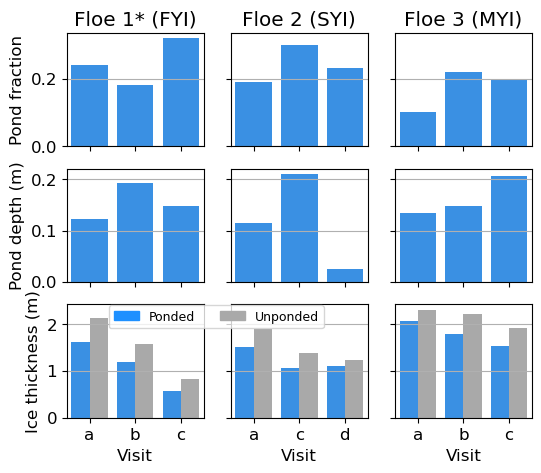

In [91]:
## Plot pond summary
mpl.rcParams["font.size"] = 12
l_fs = 9

f, axs = plt.subplots(3, 3, sharey='row', sharex='col', figsize=(6,5))

for i in np.arange(3):
    floe = str(i+1)
    df_temp = df_trn.xs(floe)
    sns.barplot(df_temp, x='visit', y='ap', ax=axs[0,i])
    sns.barplot(df_temp, x='visit', y='hp', ax=axs[1,i])
    df_temp = df_temp[['hi_b', 'hi_p']].melt(ignore_index=False, var_name='variable')
    sns.barplot(df_temp, x='visit', y='value', hue='variable', 
                hue_order=['hi_p', 'hi_b'], ax=axs[2,i], legend=False)
    axs[2,i].set_xlabel('Visit')
    
for ax in np.ravel(axs):
    ax.grid(which='both', axis='y')

axs[0,0].set_ylabel('Pond fraction')
axs[1,0].set_ylabel('Pond depth (m)')
axs[2,0].set_ylabel('Ice thickness (m)')

axs[0,0].set_title('Floe 1* (FYI)')
axs[0,1].set_title('Floe 2 (SYI)')
axs[0,2].set_title('Floe 3 (MYI)')

blue_patch = mpatches.Patch(color='C0', label='Ponded')
orange_patch = mpatches.Patch(color='C1', label='Unponded')
axs[2,2].legend(handles=[blue_patch, orange_patch], fontsize=l_fs,
               ncol=2, loc='upper left', bbox_to_anchor=[-2.14, 1.05])

f.savefig(os.path.join('..', 'figures', 'contrasts_ap_hp_hi_20260319.png'),
          transparent=True, bbox_inches='tight')

In [24]:
## Summarize bulk core properties
# Check bulk cores before future analysis!!!!!
cores_exclude = ['20250726-PS149_21-1-SI_corer_9cm-020-FYI-lead-T',
                 '20250726-PS149_21-1-SI_corer_9cm-021-FYI-lead-SALO18',
                 '20250726-PS149_21-1-SI_corer_9cm-022-FYI-lead-RHO',
                 '20250730-PS149_25-1-SI_corer_9cm-021-SMYI-RHO',
                 '20250814-PS149_36-1-SI_corer_9cm-021-SYI-SALO18',
                ]

ls_s = []
ls_r = []
ls_p = []
ls_a = []
df_temp = df_cores.query('name not in @cores_exclude')
for idx, ic in df_temp.core.items():
    if 'salinity' in ic.units:
        ls_s.append(ic.bulk_property('salinity'))
    else:
        ls_s.append(np.nan)
    if 'density' in ic.units:
        ls_r.append(ic.bulk_property('density'))
    else:
        ls_r.append(np.nan)
    ls_p.append(ic.ponded)
    ls_a.append(ic.age)
df_bulk = pd.DataFrame({'salinity': ls_s, 'density': ls_r, 
                        'ponded': ls_p, 'age': ls_a}, index=df_temp.index)
df_bulk.set_index(['ponded', 'age'], append=True, inplace=True)
df_bulk = df_bulk.melt(ignore_index=False).dropna(how='any')
df_bulk = df_bulk.reset_index().drop(columns=['name']).groupby(
    by=['station', 'visit', 'ponded', 'age', 'variable']).mean()

In [67]:
df_bulk

value
station visit ponded age              variable          
1       a     False  FY (first year)  density   0.892649
                                      salinity  2.555756
        b     False  FY (first year)  density   0.887525
                                      salinity  3.489162
              True   FY (first year)  density   0.875120
                                      salinity  0.206250
        c     False  FY (first year)  density   0.870453
                                      salinity  2.314925
              True   FY (first year)  density   0.866960
                                      salinity  1.332727
2       a     False  FY (first year)  density   0.897606
                                      salinity  3.215517
        b     False  FY (first year)  density   0.889040
                                      salinity  2.441778
              True   FY (first year)  density   0.886325
                                      salinity  1.739777
        c     False  FY (first year)  density   0.871245
                                      salinity  2.005825
              True   SY (second year) density   0.847770
                                      salinity  0.521212
        d     False  FY (first year)  density   0.876995
                                      salinity  1.755215
              True   SY (second year) density   0.850345
                                      salinity  1.225926
3       a     False  SY (second year) density   0.908173
                                      salinity  2.003304
        b     False  SY (second year) density   0.901609
                                      salinity  1.794286
              True   SY (second year) density   0.886375
                                      salinity  0.870455
        c     False  SY (second year) density   0.888365
                                      salinity  1.257419
              True   SY (second year) density   0.854972
                                      salinity  0.055645
        d     False  SY (second year) density   0.892648
                                      salinity  1.209878

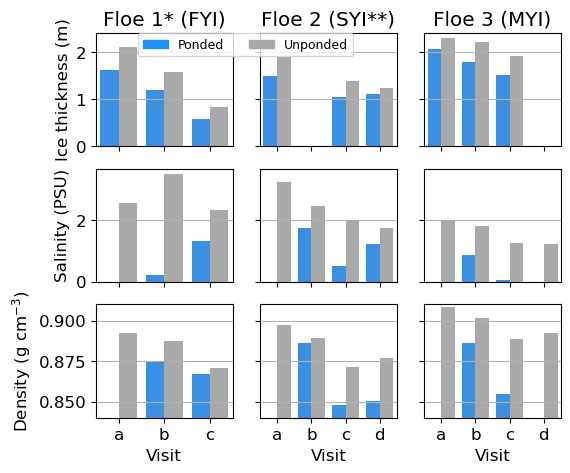

In [92]:
## Plot pond ice prop summary
mpl.rcParams["font.size"] = 12
l_fs = 9

f, axs = plt.subplots(3, 3, sharey='row', sharex='col', figsize=(6,5))

for i in np.arange(3):
    floe = str(i+1)
    df_temp = df_bulk.xs((floe, 'salinity'), level=['station', 'variable'])
    sns.barplot(df_temp, x='visit', y='value', hue='ponded', 
                hue_order=[True, False], ax=axs[1,i], legend=False)
    df_temp = df_bulk.xs((floe, 'density'), level=['station', 'variable'])
    sns.barplot(df_temp, x='visit', y='value', hue='ponded', 
                hue_order=[True, False], ax=axs[2,i], legend=False)
    df_temp = df_trn.xs(floe)
    df_temp = df_temp[['hi_b', 'hi_p']].melt(ignore_index=False, var_name='variable')
    sns.barplot(df_temp, x='visit', y='value', hue='variable', 
                hue_order=['hi_p', 'hi_b'], ax=axs[0,i], legend=False)

    axs[2,i].set_xlabel('Visit')
    
    
for ax in np.ravel(axs):
    ax.grid(which='both', axis='y')

axs[0,0].set_ylabel('Ice thickness (m)')
axs[1,0].set_ylabel('Salinity (PSU)')
axs[2,0].set_ylabel('Density (g cm$^{-3}$)')

axs[0,0].set_title('Floe 1* (FYI)')
axs[0,1].set_title('Floe 2 (SYI**)')
axs[0,2].set_title('Floe 3 (MYI)')

axs[2,0].set_ylim([0.84, 0.91])

blue_patch = mpatches.Patch(color='C0', label='Ponded')
orange_patch = mpatches.Patch(color='C1', label='Unponded')
axs[0,2].legend(handles=[blue_patch, orange_patch], fontsize=l_fs,
               ncol=2, loc='upper left', bbox_to_anchor=[-2.14, 1.05])

f.savefig(os.path.join('..', 'figures', 'contrasts_hi_sal_rho_20260319.png'),
          transparent=True, bbox_inches='tight')

In [64]:
# Create estimates of integrated, floe-scale properties
df_int = df_bulk.copy()
df_int.index = [df_int.index.get_level_values('station').rename('floe'),
                df_int.index.get_level_values('visit'),
                [v + '_p' if p else v + '_b' for p, v in zip (df_bulk.index.get_level_values('ponded'), df_bulk.index.get_level_values('variable'))],
               ]
df_int = df_int.reset_index(level=2).pivot(columns='level_2', values='value')
df_int = pd.merge(df_trn[['ap', 'hi', 'hi_b', 'hi_p']], df_int.dropna(), left_index=True, right_index=True)

df_int['sal_bulk_true'] = df_int.ap * df_int.salinity_p + (1 - df_int.ap) * df_int.salinity_b
df_int['sal_bulk_sameice'] = df_int.ap * df_int.salinity_b + (1 - df_int.ap) * df_int.salinity_b

# To estimate the freeboard, assuming pond surfaces are at sea level
# general eqn is: gravitational force of ice above freeboard = buoyancy force of submerged ice
# g force above freeboard = rho_b*(1-ap)*frbd_b * g
# buoyancy force = [(rho_w-rho_b)(1-ap)*(hi_b-frbd_b) + (rho_w-rho_p)*ap*hi_p] * g
# rho_b*(1-ap) * frbd_b = (rho_w-rho_b)(1-ap)*hi_b - (rho_w-rho_b)(1-ap)*frbd_b + (rho_w-rho_p)*ap*hi_p
# rho_b*(1-ap) * frbd_b + (rho_w-rho_b)(1-ap)*frbd_b = (rho_w-rho_b)(1-ap)*hi_b + (rho_w-rho_p)*ap*hi_p
# frbd_b = [(rho_w-rho_b)(1-ap)*hi_b + (rho_w-rho_p)*ap*hi_p] / [rho_w*(1-ap)]
# true freeboard is the freeboard of the bare ice multiplied by bare ice fraction (1-ap)
# frbd = [(rho_w-rho_b)(1-ap)*hi_b + (rho_w-rho_p)*ap*hi_p] / [rho_w]
# frbd = (1-rho_b/rho_w)(1-ap)*hi_b + (1-rho_p/rho_w)*ap*hi_p
rho_w = 1.026 # g/cm3
df_int['frbd_bulk_true'] = (1-df_int.density_b/rho_w)*(1-df_int.ap)*df_int.hi_b + (1-df_int.density_p/rho_w)*df_int.ap*df_int.hi_p
df_int['frbd_bulk_sameice'] = (1-df_int.density_b/rho_w)*(1-df_int.ap)*df_int.hi_b + (1-df_int.density_b/rho_w)*df_int.ap*df_int.hi_p


In [119]:
df_int

ap    hi  hi_b  hi_p  density_b  density_p  salinity_b  \
floe visit                                                             
1    b      0.18  1.50  1.57  1.19   0.887525   0.875120    3.489162   
     c      0.32  0.75  0.83  0.57   0.870453   0.866960    2.314925   
2    c      0.30  1.28  1.38  1.05   0.871245   0.847770    2.005825   
     d      0.23  1.21  1.24  1.10   0.876995   0.850345    1.755215   
3    b      0.22  2.12  2.21  1.78   0.901609   0.886375    1.794286   
     c      0.20  1.83  1.91  1.52   0.888365   0.854972    1.257419   

            salinity_p  sal_bulk_true  sal_bulk_sameice  frbd_bulk_true  \
floe visit                                                                
1    b        0.206250       2.898238          3.489162        0.205254   
     c        1.332727       2.000622          2.314925        0.113840   
2    c        0.521212       1.560441          2.005825        0.200425   
     d        1.225926       1.633479          1.755215        0.181980   
3    b        0.870455       1.591043          1.794286        0.262283   
     c        0.055645       1.017064          1.257419        0.255652   

            frbd_bulk_sameice  
floe visit                     
1    b               0.202664  
     c               0.113219  
2    c               0.193217  
     d               0.175408  
3    b               0.256469  
     c               0.245758

In [65]:
(df_int.sal_bulk_sameice - df_int.sal_bulk_true) / df_int.sal_bulk_true

floe  visit
1     b        0.203891
      c        0.157103
2     c        0.285422
      d        0.074526
3     b        0.127742
      c        0.236322
dtype: float64

In [66]:
(df_int.frbd_bulk_sameice - df_int.frbd_bulk_true) / df_int.frbd_bulk_true

floe  visit
1     b       -0.012618
      c       -0.005455
2     c       -0.035960
      d       -0.036112
3     b       -0.022168
      c       -0.038701
dtype: float64

## Core profiles

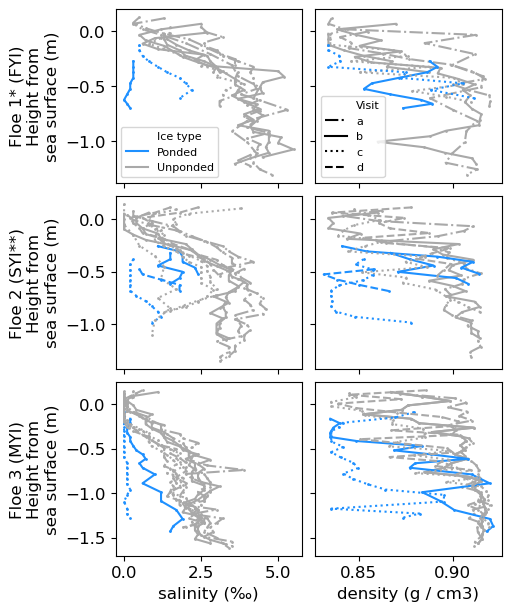

In [106]:
# Plot all salinities and densities
mpl.rcParams["font.size"] = 12
l_fs = 8

f, axs = plt.subplots(3, 2, sharex='col', sharey='row', figsize=(5, 6), constrained_layout=True)

stations = ['1', '2', '3']

style_dict = {'a': '-.',
              'b': '-',
              'c': ':',
              'd': '--',
             }

kind = 'center'
markersize = 1

for i, station in enumerate(stations):
    df_temp = df_cores.query('station == @station').reset_index()
    for tup in df_temp.itertuples():
        if tup[3] == '20250730-PS149_25-1-SI_corer_9cm-021-SMYI-RHO':
            continue # input is missing draft and freeboard, skip for now
        
        visit = tup[2]
        ic = tup[4]
        if ic.ponded:
            c = 'C0'
        else:
            c = 'C1'
        if 'salinity' in ic.units:
            #print(tup[3])
            ic.plot_profile(axs[i,0], 'salinity', z_ref='sea surface',
                            color=c, linestyle=style_dict[visit],
                           kind=kind, markersize=markersize)
        if 'density' in ic.units:
            #print(tup[3])
            ic.plot_profile(axs[i,1], 'density', z_ref='sea surface',
                            color=c, linestyle=style_dict[visit],
                           kind=kind, markersize=markersize)

for i in [0, 1, 2]:
    axs[i,1].set_ylabel("")
for i in [0, 1]:
    axs[0,i].set_xlabel("")
    axs[1,i].set_xlabel("")

axs[0,0].set_ylabel("Floe 1* (FYI)\nHeight from\nsea surface (m)")
axs[1,0].set_ylabel("Floe 2 (SYI**)\nHeight from\nsea surface (m)")
axs[2,0].set_ylabel("Floe 3 (MYI)\nHeight from\nsea surface (m)")

# legends
h = [mlines.Line2D([], [], color='blue', linestyle='', label='Ice type'),
     mlines.Line2D([], [], color='C0', linestyle='-', label='Ponded'),
     mlines.Line2D([], [], color='C1', linestyle='-', label='Unponded')]
axs[0,0].legend(handles=h, loc='lower left', fontsize=l_fs)
h = [mlines.Line2D([], [], color='blue', linestyle='', label='Visit'),
     mlines.Line2D([], [], color='k', linestyle='-.', label='a'),
     mlines.Line2D([], [], color='k', linestyle='-', label='b'),
     mlines.Line2D([], [], color='k', linestyle=':', label='c'),
     mlines.Line2D([], [], color='k', linestyle='--', label='d')]
axs[0,1].legend(handles=h, loc='lower left', fontsize=l_fs)

f.savefig(os.path.join('..', 'figures', 'contrasts_allcores_arc_sys_sci.png'),
          transparent=True, bbox_inches='tight')

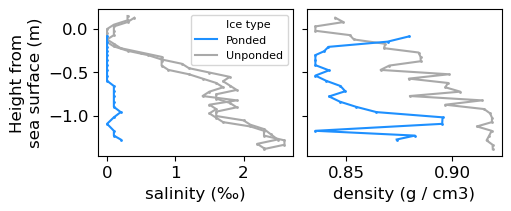

In [109]:
# Plot just floe 3 visit c

# Plot all salinities and densities
mpl.rcParams["font.size"] = 12
l_fs = 8

f, axs = plt.subplots(1, 2, sharex='col', sharey='row', figsize=(5, 2), constrained_layout=True)

kind = 'center'
markersize = 1

df_temp = df_cores.query('station=="3" & visit=="c"').reset_index()
for tup in df_temp.itertuples():
    ic = tup[4]
    if ic.ponded:
        c = 'C0'
    else:
        c = 'C1'
    if 'salinity' in ic.units:
        #print(tup[3])
        ic.plot_profile(axs[0], 'salinity', z_ref='sea surface',
                        color=c, 
                       kind=kind, markersize=markersize)
    if 'density' in ic.units:
        #print(tup[3])
        ic.plot_profile(axs[1], 'density', z_ref='sea surface',
                        color=c,
                       kind=kind, markersize=markersize)

axs[1].set_ylabel("")
axs[0].set_ylabel("Height from\nsea surface (m)")

# legends
h = [mlines.Line2D([], [], color='blue', linestyle='', label='Ice type'),
     mlines.Line2D([], [], color='C0', linestyle='-', label='Ponded'),
     mlines.Line2D([], [], color='C1', linestyle='-', label='Unponded')]
axs[0].legend(handles=h, loc='upper right', fontsize=l_fs)

f.savefig(os.path.join('..', 'figures', 'contrasts_r3c_cores_arc_sys_sci.png'),
          transparent=True, bbox_inches='tight')

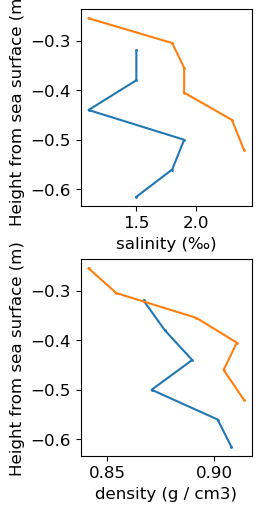

In [115]:
# Plot floe 2 visit b ponds for comparison with optics
mpl.rcParams["font.size"] = 12
l_fs = 8

f, axs = plt.subplots(2, 1, figsize=(2.5, 5), constrained_layout=True)

kind = 'center'
markersize = 1

# NEpond (bright)
ic = df_cores.at[('2', 'b', '20250731-PS149_25-1-SI_corer_9cm-024-FYI-NE-melt_pond-RHO-TXT'), 'core']
c = 'tab:blue'
ic.plot_profile(axs[0], 'salinity', z_ref='sea surface', color=c, 
               kind=kind, markersize=markersize)
ic.plot_profile(axs[1], 'density', z_ref='sea surface',
                color=c, kind=kind, markersize=markersize)

# Spond (dark)
ic = df_cores.at[('2', 'b', '20250731-PS149_25-1-SI_corer_9cm-023-FYI-S-melt_pond-RHO-TXT'), 'core']
c = 'tab:orange'
ic.plot_profile(axs[0], 'salinity', z_ref='sea surface', color=c, 
               kind=kind, markersize=markersize)
ic.plot_profile(axs[1], 'density', z_ref='sea surface',
                color=c, kind=kind, markersize=markersize)

axs[0].set_ylabel("Height from sea surface (m)")
axs[1].set_ylabel("Height from sea surface (m)")

f.savefig(os.path.join('..', 'figures', 'contrasts_r2b_pondcores_arc_sys_sci.png'),
          transparent=True, bbox_inches='tight')

In [117]:
df_cores.query('station=="2" & visit=="c"')

core  \
station visit name                                                                                                  
2       c     20250812-PS149_36-1-SI_corer_9cm-016-FYI-SALO18     <__main__.IceCore object at 0x0000029B3FC707D0>   
              20250812-PS149_36-1-SI_corer_9cm-017-FYI-T          <__main__.IceCore object at 0x0000029B3FC734D0>   
              20250812-PS149_36-1-SI_corer_9cm-018-FYI-REP        <__main__.IceCore object at 0x0000029B3FC70C80>   
              20250812-PS149_36-1-SI_corer_9cm-019-FYI-RHO        <__main__.IceCore object at 0x0000029B3FC715E0>   
              20250813-PS149_36-1-SI_corer_9cm-020-FYI-T3-mel...  <__main__.IceCore object at 0x0000029B3FC73D40>   
              20250814-PS149_36-1-SI_corer_9cm-021-SYI-SALO18     <__main__.IceCore object at 0x0000029B3FC714F0>   

                                                                                 timestamp  
station visit name                                                                          
2       c     20250812-PS149_36-1-SI_corer_9cm-016-FYI-SALO18    2025-08-12 11:01:00+00:00  
              20250812-PS149_36-1-SI_corer_9cm-017-FYI-T         2025-08-12 11:01:00+00:00  
              20250812-PS149_36-1-SI_corer_9cm-018-FYI-REP       2025-08-12 11:01:00+00:00  
              20250812-PS149_36-1-SI_corer_9cm-019-FYI-RHO       2025-08-12 11:01:00+00:00  
              20250813-PS149_36-1-SI_corer_9cm-020-FYI-T3-mel... 2025-08-13 10:15:00+00:00  
              20250814-PS149_36-1-SI_corer_9cm-021-SYI-SALO18    2025-08-14 13:54:00+00:00

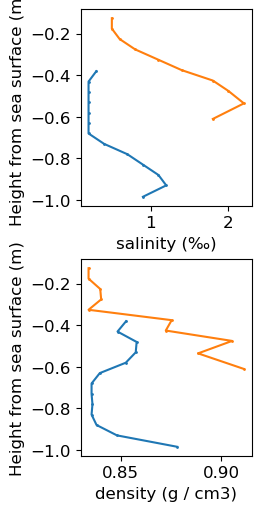

In [118]:
# Plot floe 1 (fyi) v floe 2 (syi) visit c ponds
mpl.rcParams["font.size"] = 12
l_fs = 8

f, axs = plt.subplots(2, 1, figsize=(2.5, 5), constrained_layout=True)

kind = 'center'
markersize = 1

# NEpond (bright)
ic = df_cores.at[('2', 'c', '20250813-PS149_36-1-SI_corer_9cm-020-FYI-T3-melt_pond-RHO-TXT'), 'core']
c = 'tab:blue'
ic.plot_profile(axs[0], 'salinity', z_ref='sea surface', color=c, 
               kind=kind, markersize=markersize)
ic.plot_profile(axs[1], 'density', z_ref='sea surface',
                color=c, kind=kind, markersize=markersize)

# Spond (dark)
ic = df_cores.at[('1', 'c', '20250810-PS149_32-1-SI_corer_9cm-020-FYI-melt_pond-RHO-TXT'), 'core']
c = 'tab:orange'
ic.plot_profile(axs[0], 'salinity', z_ref='sea surface', color=c, 
               kind=kind, markersize=markersize)
ic.plot_profile(axs[1], 'density', z_ref='sea surface',
                color=c, kind=kind, markersize=markersize)

axs[0].set_ylabel("Height from sea surface (m)")
axs[1].set_ylabel("Height from sea surface (m)")

f.savefig(os.path.join('..', 'figures', 'contrasts_r1c_r2c_pondcores_arc_sys_sci.png'),
          transparent=True, bbox_inches='tight')